# Data Understanding

In [35]:
import os
import json
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from utils import parse_number
from config import (
  RAW_REGENCIES_CSV,
  RAW_PROVINCES_CSV,
  UNDERSTANDING_PROVINCES_CSV,
  UNDERSTANDING_REGENCIES_CSV,
  FEATURE_EVALUATION_JSON,
  PROVINCE_COLUMN_MAPPING,
  REGENCY_COLUMN_MAPPING
)

In [19]:
# Memuat dataset hasil scraping mentah
df_prov = pd.read_csv(RAW_PROVINCES_CSV, dtype=str)
df_reg = pd.read_csv(RAW_REGENCIES_CSV, dtype=str)

# Pemetaan nama kolom ke format standar
df_prov = df_prov.rename(columns=PROVINCE_COLUMN_MAPPING)
df_reg = df_reg.rename(columns=REGENCY_COLUMN_MAPPING)

In [20]:
PROVINCES_IGNORED_FORMATTED_COLS = ('no', 'province_name')
REGENCIES_IGNORED_FORMATTED_COLS = ('province_id', 'regency_no', 'regency_name')

for col in df_prov.columns:
  if col not in PROVINCES_IGNORED_FORMATTED_COLS:
    df_prov[col] = df_prov[col].apply(parse_number)

for col in df_reg.columns:
  if col not in REGENCIES_IGNORED_FORMATTED_COLS:
    df_reg[col] = df_reg[col].apply(parse_number)

In [21]:
df_prov.to_csv(UNDERSTANDING_PROVINCES_CSV, index=False)
df_reg.to_csv(UNDERSTANDING_REGENCIES_CSV, index=False)

In [22]:
print(df_prov.head().to_markdown(index=False))

|   no | province_name              |   total_koperasi |   koperasi_nib |   koperasi_npwp |   koperasi_rat |   simpanan_pokok |   simpanan_wajib |   volume_transaksi |   nilai_transaksi |   pemetahaan_lahan |   pemetahaan_lahan_pct |   pembangunan_gerai_pct |
|-----:|:---------------------------|-----------------:|---------------:|----------------:|---------------:|-----------------:|-----------------:|-------------------:|------------------:|-------------------:|-----------------------:|------------------------:|
|    1 | ACEH                       |             6534 |           4451 |            6529 |           4472 |      3.33204e+08 |      1.05585e+08 |             201425 |       7.06134e+08 |               1826 |                  28.1  |                   82.14 |
|    2 | BALI                       |              718 |            499 |             716 |            642 |      9.46365e+08 |      4.82421e+08 |             479373 |       3.51114e+09 |                142 |            

In [23]:
print(df_reg.head().to_markdown(index=False))

|   province_id |   regency_no | regency_name   |   total_koperasi |   koperasi_nib |   koperasi_npwp |   koperasi_rat |   simpanan_pokok |   simpanan_wajib |   volume_transaksi |   nilai_transaksi |
|--------------:|-------------:|:---------------|-----------------:|---------------:|----------------:|---------------:|-----------------:|-----------------:|-------------------:|------------------:|
|            17 |            1 | KAB. BADUNG    |               64 |             39 |              63 |             59 |       2.735e+07  |        3.43e+06  |              65091 |       2.03328e+08 |
|            17 |            2 | KAB. BANGLI    |               72 |             37 |              72 |             72 |       2.0123e+08 |        5.141e+07 |                  0 |       0           |
|            17 |            3 | KAB. BULELENG  |              148 |             97 |             147 |            121 |       8.4915e+07 |        4.425e+07 |              35197 |       4.17694e+08 |


## Statistik Deskriptif

In [24]:
df_stats = df_reg.describe().T
print(df_stats.to_markdown())

|                  |   count |            mean |              std |   min |          25% |            50% |             75% |           max |
|:-----------------|--------:|----------------:|-----------------:|------:|-------------:|---------------:|----------------:|--------------:|
| total_koperasi   |     514 |   162.216       |    116.262       |     6 | 74.25        |  136           |   222.75        | 852           |
| koperasi_nib     |     514 |   118.325       |    100.51        |     0 | 46           |   86           |   160           | 570           |
| koperasi_npwp    |     514 |   157.545       |    114.335       |     6 | 71.25        |  132.5         |   218.5         | 852           |
| koperasi_rat     |     514 |    97.6206      |     89.5316      |     0 | 34.25        |   71           |   138           | 596           |
| simpanan_pokok   |     514 |     5.74449e+07 |      1.55116e+08 |     0 |  4.9125e+06  |    2.088e+07   |     6.114e+07   |   2.29473e+09 |
| simp

In [25]:
total_koperasi = int(df_prov['total_koperasi'].sum())
nib_sum = int(df_prov['koperasi_nib'].sum())
npwp_sum = int(df_prov['koperasi_npwp'].sum())
rat_sum = int(df_prov['koperasi_rat'].sum())
pct_nib = round(nib_sum / total_koperasi * 100, 2) if total_koperasi > 0 else 0.0
pct_npwp = round(npwp_sum / total_koperasi * 100, 2) if total_koperasi > 0 else 0.0
pct_rat = round(rat_sum / total_koperasi * 100, 2) if total_koperasi > 0 else 0.0
simpanan_pokok = float(df_prov['simpanan_pokok'].sum())
simpanan_wajib = float(df_prov['simpanan_wajib'].sum())
nilai_transaksi = float(df_prov['nilai_transaksi'].sum())

print(f"Total Kabupaten/Kota       : {len(df_reg)}")
print(f"Total Koperasi Terdata     : {total_koperasi:,} unit")
print(f"Koperasi Memiliki NIB      : {nib_sum:,} ({pct_nib}%)")
print(f"Koperasi Memiliki NPWP     : {npwp_sum:,} ({pct_npwp}%)")
print(f"Koperasi Telah RAT         : {rat_sum:,} ({pct_rat}%)")
print(f"Akumulasi Simpanan Pokok   : Rp {simpanan_pokok:,.2f}")
print(f"Akumulasi Simpanan Wajib   : Rp {simpanan_wajib:,.2f}")
print(f"Total Nilai Transaksi      : Rp {nilai_transaksi:,.2f}")

Total Kabupaten/Kota       : 514
Total Koperasi Terdata     : 83,379 unit
Koperasi Memiliki NIB      : 60,820 (72.94%)
Koperasi Memiliki NPWP     : 80,979 (97.12%)
Koperasi Telah RAT         : 50,177 (60.18%)
Akumulasi Simpanan Pokok   : Rp 29,526,666,715.00
Akumulasi Simpanan Wajib   : Rp 11,008,470,350.00
Total Nilai Transaksi      : Rp 205,689,131,984.00


## Eksplorasi Data

### Heatmap Korelasi Pearson

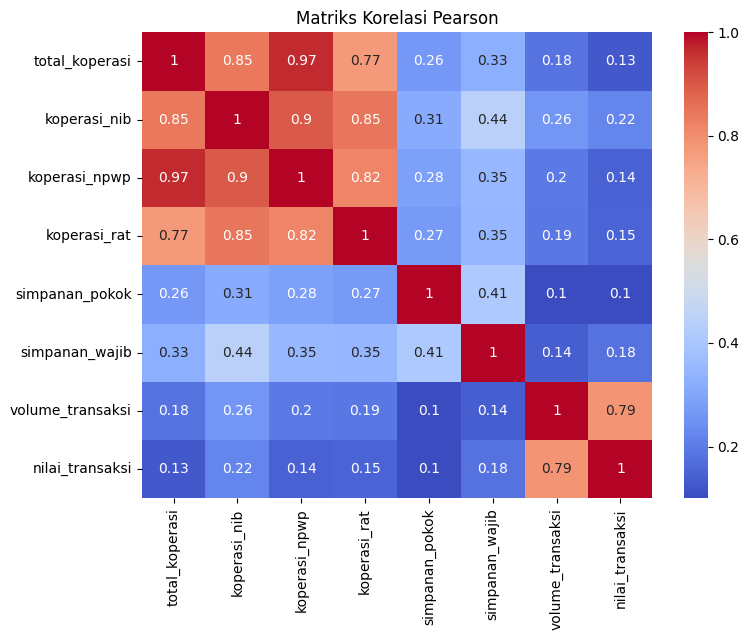

In [26]:
corr_matrix = df_reg.select_dtypes('number').corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Matriks Korelasi Pearson')
plt.tight_layout()
plt.show()

### Barplot Top Provinsi Jumlah Koperasi

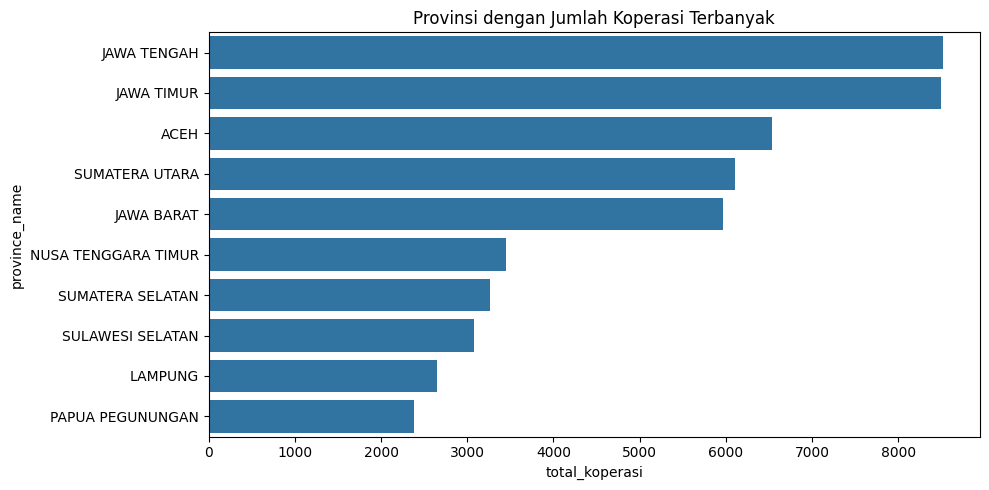

In [27]:
TOP_PROVINCES_LIMIT = 10

top_prov = df_prov.sort_values(by='total_koperasi', ascending=False).head(TOP_PROVINCES_LIMIT)

plt.figure(figsize=(10, 5))
sns.barplot(x='total_koperasi', y='province_name', data=top_prov)
plt.title('Provinsi dengan Jumlah Koperasi Terbanyak')
plt.tight_layout()
plt.show()

### Barplot Top Kabupaten/Kota Nilai Transaksi

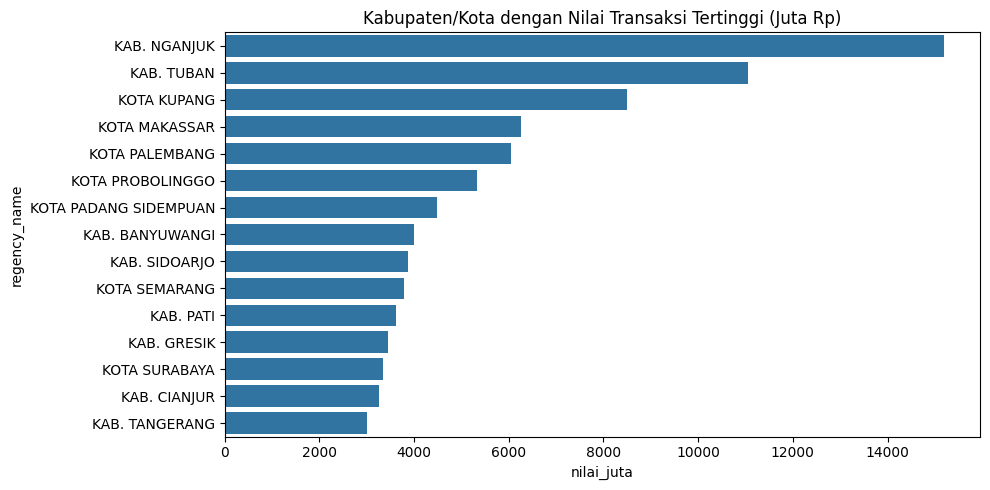

In [28]:
TOP_REGENCIES_LIMIT = 15

top_reg = df_reg.sort_values(by='nilai_transaksi', ascending=False).head(TOP_REGENCIES_LIMIT).copy()
top_reg['nilai_juta'] = top_reg['nilai_transaksi'] / 1e6

plt.figure(figsize=(10, 5))
sns.barplot(x='nilai_juta', y='regency_name', data=top_reg)
plt.title('Kabupaten/Kota dengan Nilai Transaksi Tertinggi (Juta Rp)')
plt.tight_layout()
plt.show()

### Distribusi Fitur

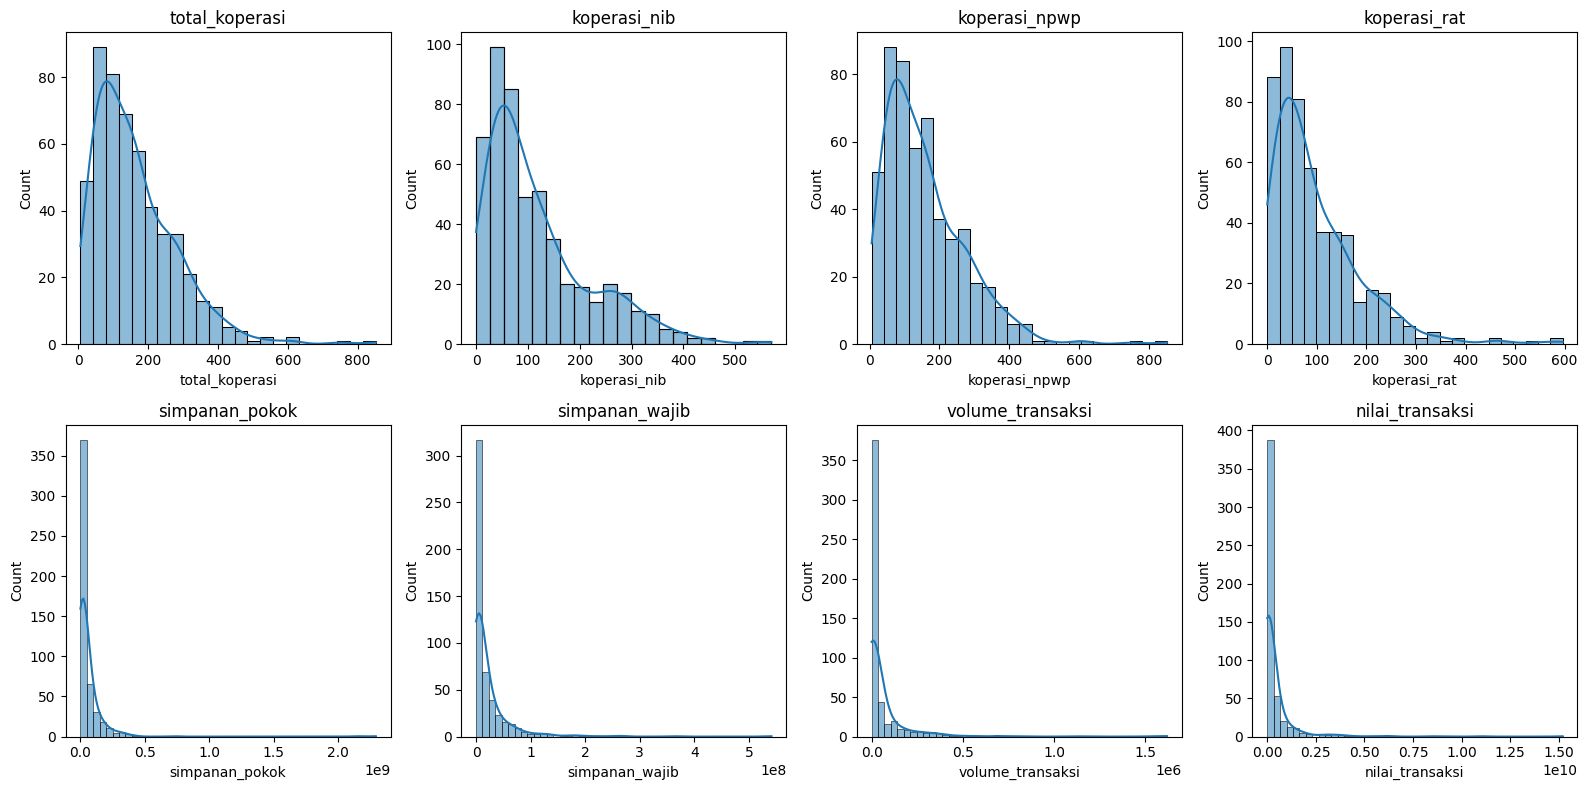

In [29]:
df_dist = df_reg.select_dtypes('number')

fig, axes = plt.subplots(int(np.ceil(df_dist.shape[1] / 4)), 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(df_dist.columns):
    sns.histplot(df_dist[col], kde=True, ax=axes[idx])
    axes[idx].set_title(col)

for ax in axes[df_dist.shape[1]:]:
    fig.delaxes(ax)

plt.tight_layout()
plt.show()

### Analisis Variabilitas & Koefisien Variasi

In [30]:
stats = df_reg.select_dtypes('number').agg(['mean', 'std', 'var']).T
stats['CV (%)'] = (stats['std'] / stats['mean'] * 100)

variability_df = stats.reset_index().rename(columns={'index': 'Fitur'})

print(variability_df.to_markdown(index=False))

| Fitur            |            mean |              std |             var |   CV (%) |
|:-----------------|----------------:|-----------------:|----------------:|---------:|
| total_koperasi   |   162.216       |    116.262       | 13516.7         |  71.6708 |
| koperasi_nib     |   118.325       |    100.51        | 10102.3         |  84.9441 |
| koperasi_npwp    |   157.545       |    114.335       | 13072.4         |  72.5729 |
| koperasi_rat     |    97.6206      |     89.5316      |  8015.9         |  91.7138 |
| simpanan_pokok   |     5.74449e+07 |      1.55116e+08 |     2.40609e+16 | 270.026  |
| simpanan_wajib   |     2.14173e+07 |      4.42572e+07 |     1.9587e+15  | 206.643  |
| volume_transaksi | 57288.5         | 161854           |     2.61967e+10 | 282.524  |
| nilai_transaksi  |     4.00173e+08 |      1.17303e+09 |     1.376e+18   | 293.131  |


### Uji Multikolinearitas (VIF)

In [31]:
df_vif = df_reg.select_dtypes('number').fillna(0)

X_scaled = StandardScaler().fit_transform(df_vif)
inv_corr = np.linalg.inv(np.corrcoef(X_scaled, rowvar=False))

vif_df = pd.DataFrame({
  'Fitur': df_vif.columns,
  'VIF': np.diag(inv_corr)
})

print(vif_df.to_markdown(index=False))

| Fitur            |      VIF |
|:-----------------|---------:|
| total_koperasi   | 15.5898  |
| koperasi_nib     |  7.39868 |
| koperasi_npwp    | 23.7391  |
| koperasi_rat     |  3.79515 |
| simpanan_pokok   |  1.23391 |
| simpanan_wajib   |  1.42328 |
| volume_transaksi |  2.68929 |
| nilai_transaksi  |  2.68077 |


### Penyimpanan Hasil Uji Statistik

In [32]:
feature_cols = df_reg.select_dtypes('number').columns.difference(REGENCIES_IGNORED_FORMATTED_COLS).tolist()

evaluation_results = {
  "feature_columns": feature_cols,
  "vif": vif_df.set_index('Fitur')['VIF'].to_dict(),
  "variability_cv": variability_df.set_index('Fitur')['CV (%)'].to_dict(),
  "skewness": df_reg[feature_cols].skew().to_dict()
}

with open(FEATURE_EVALUATION_JSON, 'w', encoding='utf-8') as f:
  json.dump(evaluation_results, f, indent=2)

print(f"Hasil uji statistik fitur berhasil disimpan di : {FEATURE_EVALUATION_JSON}")

Hasil uji statistik fitur berhasil disimpan di : d:\kopdes\data\1_understanding\feature_evaluation.json


## Verifikasi Kualitas Data

### Mengecek Nilai Hilang

In [33]:
df_mv = df_reg.isnull().sum()

print(df_mv.to_markdown())

|                  |   0 |
|:-----------------|----:|
| province_id      |   0 |
| regency_no       |   0 |
| regency_name     |   0 |
| total_koperasi   |   0 |
| koperasi_nib     |   0 |
| koperasi_npwp    |   0 |
| koperasi_rat     |   0 |
| simpanan_pokok   |   0 |
| simpanan_wajib   |   0 |
| volume_transaksi |   0 |
| nilai_transaksi  |   0 |


### Mengecek Outlier

In [34]:
df_num = df_reg.select_dtypes('number')

q1 = df_num.quantile(0.25)
q3 = df_num.quantile(0.75)
iqr = q3 - q1
lower = (q1 - 1.5 * iqr).clip(lower=0)
upper = q3 + 1.5 * iqr

out_cnt = ((df_num < lower) | (df_num > upper)).sum()

outliers_df = pd.DataFrame({
  'Fitur': df_num.columns,
  'Skewness': df_num.skew(),
  'Batas Bawah': lower,
  'Batas Atas': upper,
  'Outliers': out_cnt,
  'Persentase (%)': (out_cnt / len(df_num) * 100)
})

print(outliers_df.to_markdown(index=False))

| Fitur            |   Skewness |   Batas Bawah |       Batas Atas |   Outliers |   Persentase (%) |
|:-----------------|-----------:|--------------:|-----------------:|-----------:|-----------------:|
| total_koperasi   |    1.49139 |             0 |    445.5         |         11 |          2.14008 |
| koperasi_nib     |    1.32483 |             0 |    331           |         24 |          4.66926 |
| koperasi_npwp    |    1.52107 |             0 |    439.375       |          9 |          1.75097 |
| koperasi_rat     |    1.89075 |             0 |    293.625       |         16 |          3.11284 |
| simpanan_pokok   |   10.9974  |             0 |      1.45481e+08 |         51 |          9.92218 |
| simpanan_wajib   |    5.68016 |             0 |      5.53725e+07 |         54 |         10.5058  |
| volume_transaksi |    6.21935 |             0 | 100158           |         79 |         15.3696  |
| nilai_transaksi  |    7.14892 |             0 |      7.74925e+08 |         64 |         1